In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_s_curve, make_swiss_roll

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere
from metrics import evaluate_conformality

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_swiss_roll(n_samples=3000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
data = data / torch.max(torch.abs(data), axis=0)[0] # Normalize data
val_data, val_labels = make_swiss_roll(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = val_data / torch.max(torch.abs(val_data), axis=0)[0] # Normalize validation data

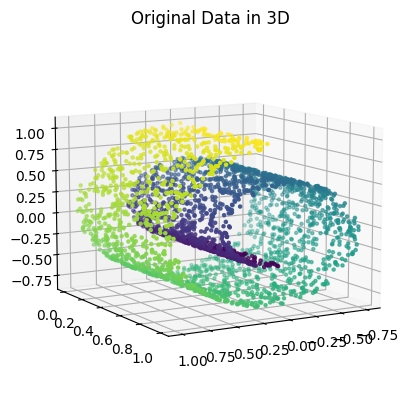

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(10, 60, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 128

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)


dir_path = "models/conformal_autoencoder_cosine_comp_realswissroll"

In [6]:
lambda_isos = np.logspace(-3, 2, 9)
lambda_isos = np.concat([np.zeros(1), lambda_isos])

In [7]:
from metrics import conformality_cosine2_loss

In [8]:
import os

def modelpath(dir_path, lambda_iso, index):
    os.makedirs(dir_path, exist_ok=True)
    return f"{dir_path}/lambda_{lambda_iso:.3f}_model_{index+1}.pth"

In [9]:
num_epochs = 1000
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_cosine2_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = modelpath(dir_path, lambda_iso, j)
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.000


/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: 0.00195653, Reconstruction Loss: 0.00195653, Conformal Loss: 0.12717776
Epoch [100/1000], Validation Loss: 0.00214775, Reconstruction Loss: 0.00214775, Conformal Loss: 0.14343430
Epoch [200/1000], Loss: 0.00102827, Reconstruction Loss: 0.00102827, Conformal Loss: 0.14517659
Epoch [200/1000], Validation Loss: 0.00130021, Reconstruction Loss: 0.00130021, Conformal Loss: 0.15945603
Epoch [300/1000], Loss: 0.00077106, Reconstruction Loss: 0.00077106, Conformal Loss: 0.15960097
Epoch [300/1000], Validation Loss: 0.00124573, Reconstruction Loss: 0.00124573, Conformal Loss: 0.16183713
Epoch [400/1000], Loss: 0.00089152, Reconstruction Loss: 0.00089152, Conformal Loss: 0.15842848
Epoch [400/1000], Validation Loss: 0.00094105, Reconstruction Loss: 0.00094105, Conformal Loss: 0.16680822
Epoch [500/1000], Loss: 0.00044127, Reconstruction Loss: 0.00044127, Conformal Loss: 0.18591376
Epoch [500/1000], Validation Loss: 0.00078238, Reconstruction Loss: 0.00078238, Conformal Lo

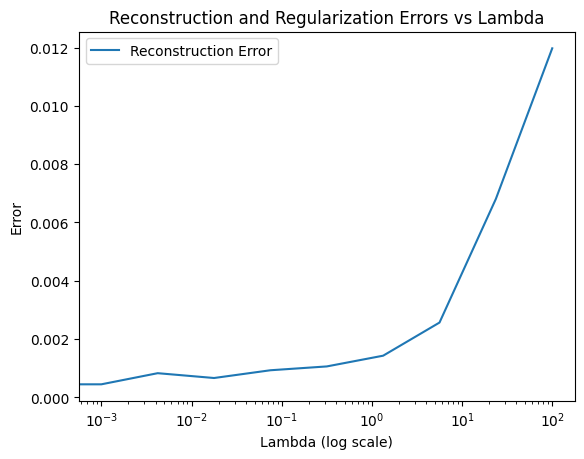

In [10]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
# plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
# plt.ylim(0, 0.06)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

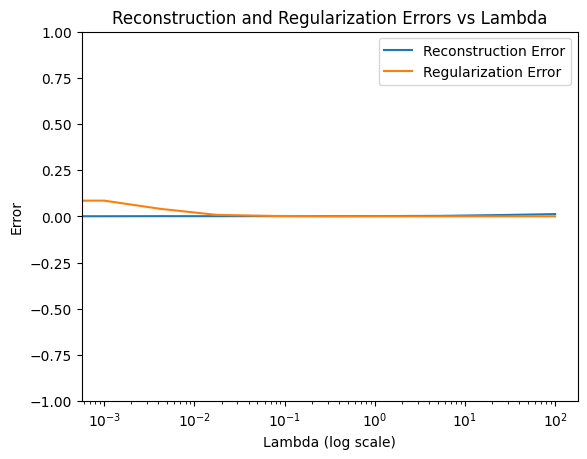

In [11]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(-1.0, 1)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

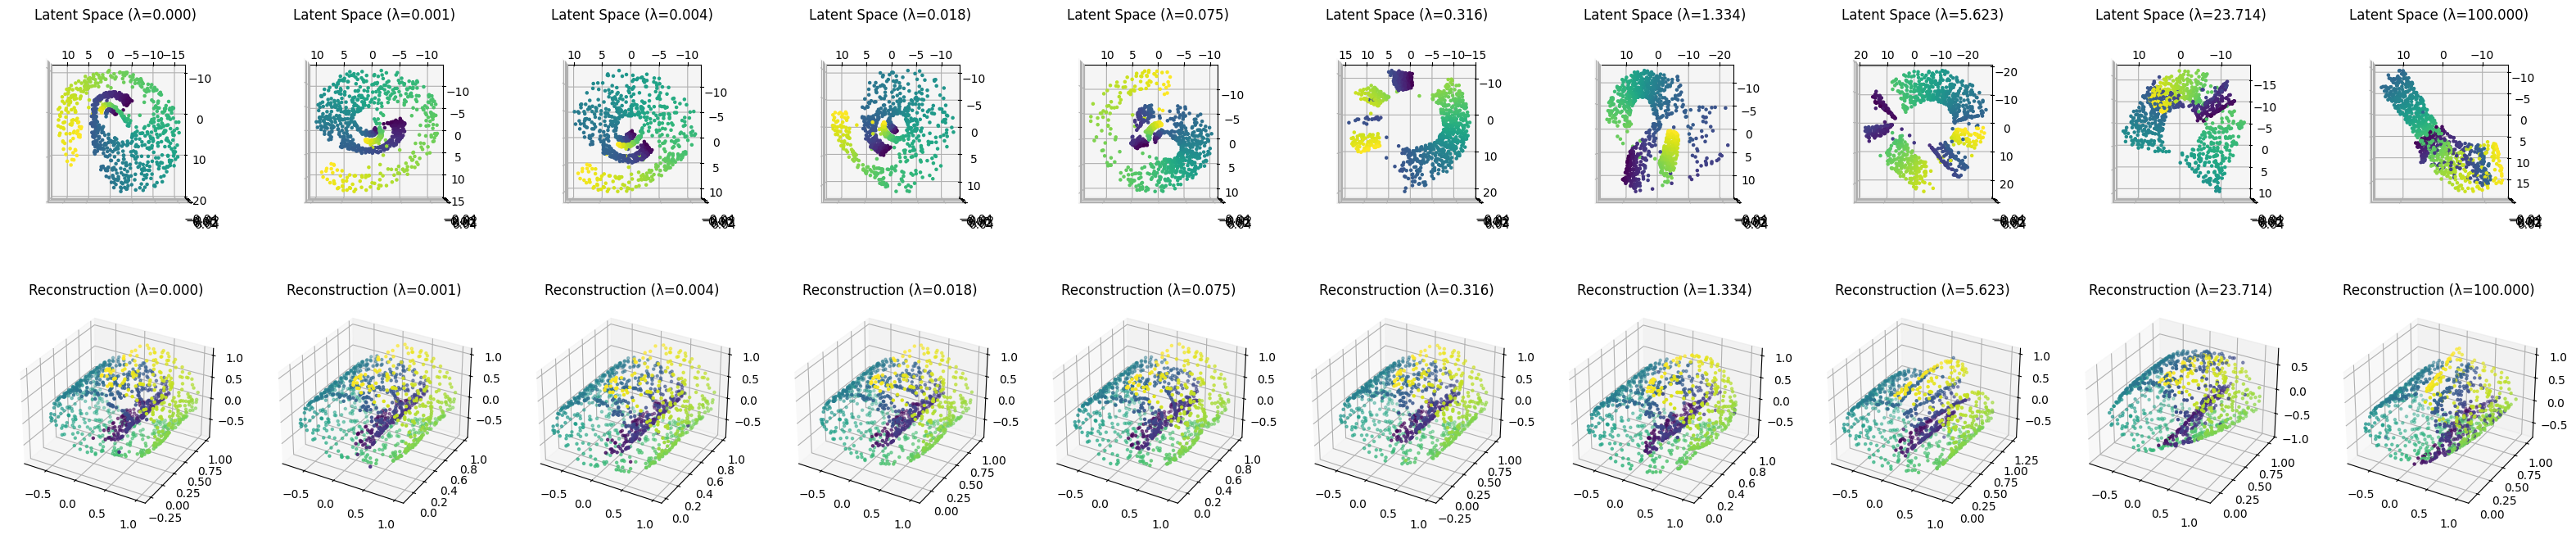

In [12]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 0)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

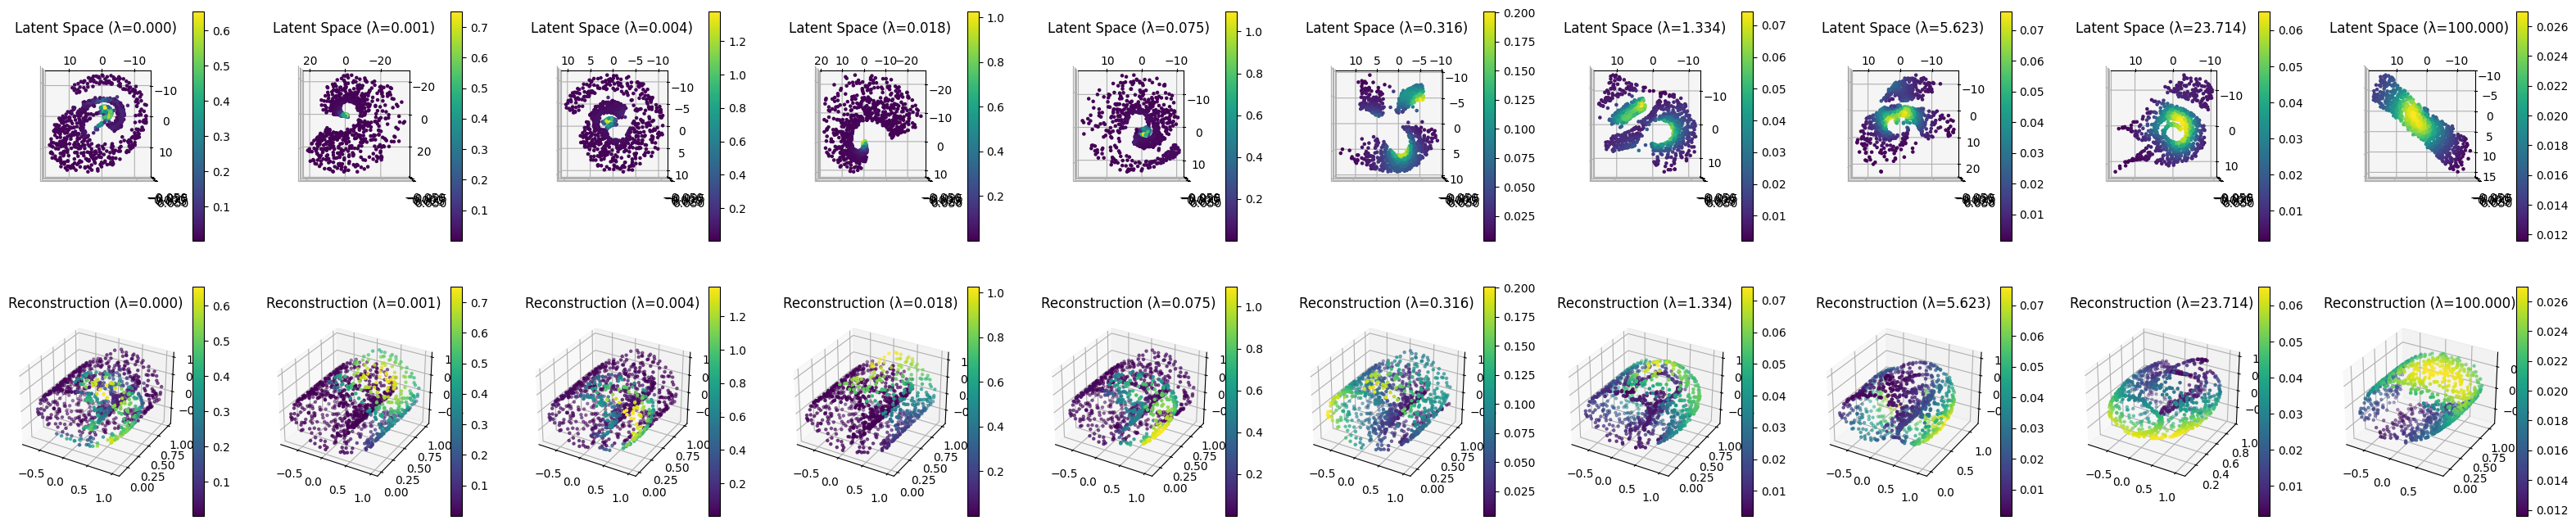

In [13]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 1)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [14]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

torch.cuda.DoubleTensor
tensor([0.0243, 0.0290, 0.4136,  ..., 0.1248, 0.3838, 1.2744], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-4.5741, -3.9450, -1.2216,  ..., -3.7446, -2.5121,  0.0502],
       device='cuda:0', dtype=torch.float64)
tensor([-3.7164, -3.5396, -0.8829,  ..., -2.0813, -0.9577,  0.2425],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.0145, 0.0168, 0.6621,  ..., 0.0845, 0.2475, 0.7974], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-4.4084, -4.3071, -0.7171,  ..., -3.8622, -2.9186, -0.2638],
       device='cuda:0', dtype=torch.float64)
tensor([-4.2366, -4.0869, -0.4123,  ..., -2.4709, -1.3965, -0.2264],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.0206, 0.0110, 0.2702,  ..., 0.1246, 0.0554, 1.0428], device='cuda:0',
       dtype=torch.flo

In [15]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            'log_determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
            'log_determinant_vs_estimate_mean',
            ], cmap='Oranges') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,log_determinant_vs_estimate_mean,log_determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.000000,0.000206,0.359937,0.228959,0.340106,1.485447,0.048294,0.136596,0.224930,0.636198,0.090236,0.199714,0.404899,0.901727,0.688763,0.240652,-0.463134,0.475873,5.948080,6.219854,5.676305,477.802032
0.001000,0.000183,0.343194,0.170800,0.241416,1.413443,0.023923,0.067665,0.141283,0.399608,0.051958,0.112528,0.312880,0.684256,0.802127,0.218416,-0.276780,0.377140,4.999140,5.046385,4.951895,395.474091
0.004217,0.000221,0.211931,0.160123,0.266608,1.665017,0.015043,0.042547,0.098992,0.279991,0.033748,0.074484,0.204957,0.451360,0.911906,0.132928,-0.107322,0.191677,4.381967,4.663663,4.100270,341.561157
0.017783,0.000256,0.076877,0.183276,0.296689,1.618806,0.008852,0.025038,0.039416,0.111485,0.018282,0.039768,0.077854,0.171853,0.987881,0.021858,-0.012449,0.023365,4.281001,4.684775,3.877228,335.516663
0.074989,0.000483,0.038343,0.145236,0.207892,1.431411,0.003687,0.010429,0.019002,0.053747,0.007085,0.015727,0.038174,0.084082,0.996841,0.005874,-0.003175,0.005983,4.606764,4.886531,4.326998,363.532776
0.316228,0.000182,0.004130,0.023364,0.012042,0.515427,0.000058,0.000165,0.002540,0.007185,0.000103,0.000230,0.004605,0.010297,0.999947,0.000102,-0.000046,0.000102,7.829186,7.876520,7.781853,630.682922
1.333521,0.001273,0.009520,0.026336,0.017070,0.648179,0.000101,0.000286,0.004482,0.012676,0.000219,0.000488,0.009242,0.020704,0.999751,0.000687,-0.000235,0.000686,6.463107,6.730412,6.195802,504.950775
5.623413,0.002065,0.005021,0.047118,0.035411,0.751541,0.000175,0.000495,0.003267,0.009240,0.000305,0.000680,0.005777,0.012927,0.999938,0.000064,-0.000057,0.000064,4.368982,4.985065,3.752899,364.644012
23.713737,0.006532,0.001895,0.014011,0.008685,0.619844,0.000012,0.000034,0.001001,0.002832,0.000023,0.000050,0.001948,0.004325,0.999979,0.000019,-0.000007,0.000012,6.520137,7.631747,5.408527,670.005554
100.000000,0.011280,0.001292,0.016873,0.010532,0.624158,0.000010,0.000028,0.000706,0.001997,0.000017,0.000038,0.001352,0.003008,0.999985,0.000013,-0.000004,0.000007,5.118972,5.261128,4.976815,538.227600


In [9]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


torch.cuda.DoubleTensor
tensor([0.6213, 0.2042, 2.0084,  ..., 0.3635, 0.5670, 0.7102], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-1.0954, -1.6739,  0.4218,  ..., -1.3809, -0.6301, -0.3650],
       device='cuda:0', dtype=torch.float64)
tensor([-0.4759, -1.5889,  0.6973,  ..., -1.0119, -0.5673, -0.3423],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([1.7715, 1.4062, 1.2324,  ..., 1.4510, 0.7043, 1.5464], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([ 0.5416,  0.1700,  0.0863,  ...,  0.3221, -0.4204,  0.2987],
       device='cuda:0', dtype=torch.float64)
tensor([ 0.5718,  0.3409,  0.2090,  ...,  0.3723, -0.3506,  0.4359],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.9276, 0.7444, 0.6094,  ..., 0.9543, 0.9126, 0.3739], device='cuda:0',
       dtype=torch.flo